In [1]:
import pandas as pd
import pandas as pd
import geopandas as gpd

import sys
sys.path.append('scripts')
from add_soil_attributes import mex_gdf, target, base_path # type:ignore

print(f"Initial Shape of the dataframe: {mex_gdf.shape}")

# drop duplicate values, excluding the bedrock column
exclude_cols = {'bedrock'}
columns_to_check = list(set(mex_gdf.columns) - exclude_cols)
mex_gdf.drop_duplicates(subset=columns_to_check, inplace=True)
print(f"Shape of the final dataset after dropping duplicates: {mex_gdf.shape}")

# drop missing values
mex_gdf.dropna(inplace=True)
print(f"Shape of the final dataset after dropping missing values: {mex_gdf.shape}")

mex_gdf.head()

Shape of the original dataset: (4936, 12)
Data converted to GeoDataFrame
        date  profile_id   longitude   latitude  upper_depth  lower_depth  \
0  1969-8-11     1358127 -100.462493  21.496251            0           15   
1  1969-8-15     1601435 -101.695887  21.741673            0           12   
2  1969-8-15     1601435 -101.695887  21.741673           12           28   
3  1969-8-21     1149366 -102.573228  22.971120            0           18   
4   1969-8-5     1184329 -101.578685  21.887564            0           15   

   clay  elcosp  orgc  phaq  sand  silt                     geometry  
0  40.0     2.0  26.0   6.3  44.0  16.0  POINT (-100.46249 21.49625)  
1  22.0     2.0   9.0   6.1  48.0  30.0  POINT (-101.69589 21.74167)  
2  26.0     2.0   6.0   6.4  46.0  28.0  POINT (-101.69589 21.74167)  
3   8.0     2.0  31.0   7.5  60.0  32.0  POINT (-102.57323 22.97112)  
4  16.0     2.0   6.0   7.1  48.0  36.0  POINT (-101.57869 21.88756)  
Soil type data loaded
                

,date,profile_id,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,geometry,soil_type,slopemean,bedrock
0,1969-8-11,1358127,-100.462493,21.496251,0,15,40.0,2.0,26.0,6.3,44.0,16.0,POINT (-100.46249 21.49625),LUVISOL CROMICO,7.946143,rocas_igneas
1,1969-8-15,1601435,-101.695887,21.741673,0,12,22.0,2.0,9.0,6.1,48.0,30.0,POINT (-101.69589 21.74167),XEROSOL LUVICO,0.397606,rocas_igneas
2,1969-8-15,1601435,-101.695887,21.741673,12,28,26.0,2.0,6.0,6.4,46.0,28.0,POINT (-101.69589 21.74167),XEROSOL LUVICO,0.397606,rocas_igneas
3,1969-8-21,1149366,-102.573228,22.971120,0,18,8.0,2.0,31.0,7.5,60.0,32.0,POINT (-102.57323 22.97112),REGOSOL CALCARICO,0.904109,rocas_sedimentarias
4,1969-8-5,1184329,-101.578685,21.887564,0,15,16.0,2.0,6.0,7.1,48.0,36.0,POINT (-101.57869 21.88756),XEROSOL HAPLICO,0.914784,rocas_igneas


In [2]:
# Get profile_ids that occur more than once
profile_counts = mex_gdf['profile_id'].value_counts()
frequent_profiles = profile_counts[profile_counts > 1].index

# Filter the dataframe to keep only those profile_ids
filtered_gdf = mex_gdf[mex_gdf['profile_id'].isin(frequent_profiles)]

print(f"Original shape: {mex_gdf.shape}")
print(f"Dataset with more than 1 depth entry: {filtered_gdf.shape}")

Original shape: (4906, 16)
Dataset with more than 1 depth entry: (1744, 16)


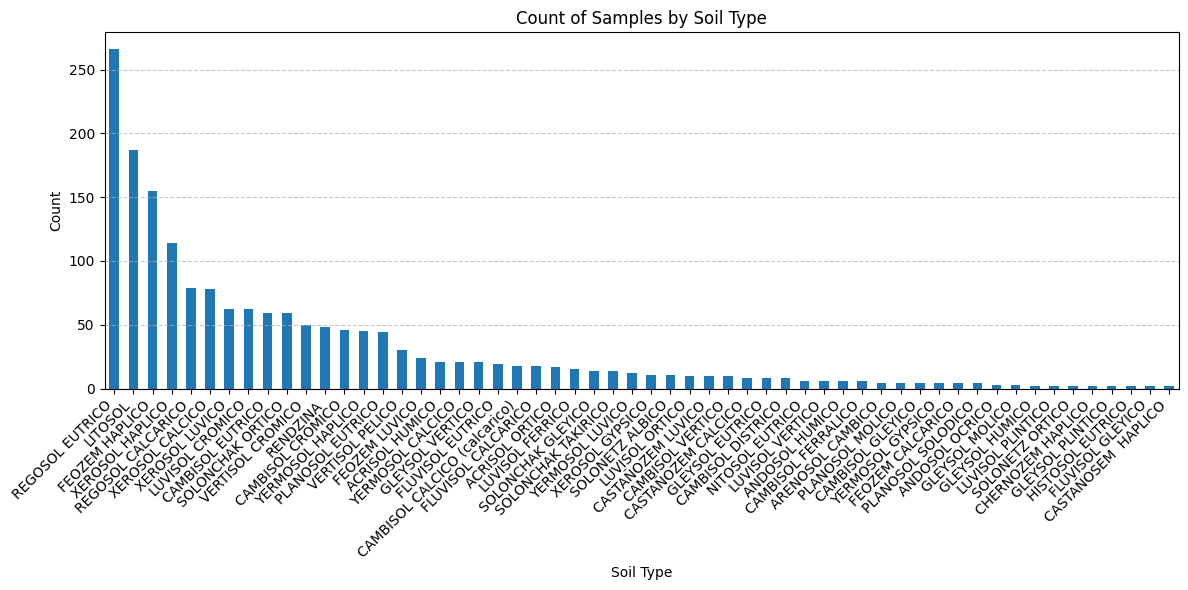

In [3]:
import matplotlib.pyplot as plt

# Create a bar plot
plt.figure(figsize=(12, 6))
soil_type_counts = filtered_gdf['soil_type'].value_counts()
soil_type_counts.plot(kind='bar')

# Customize the plot
plt.title('Count of Samples by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()

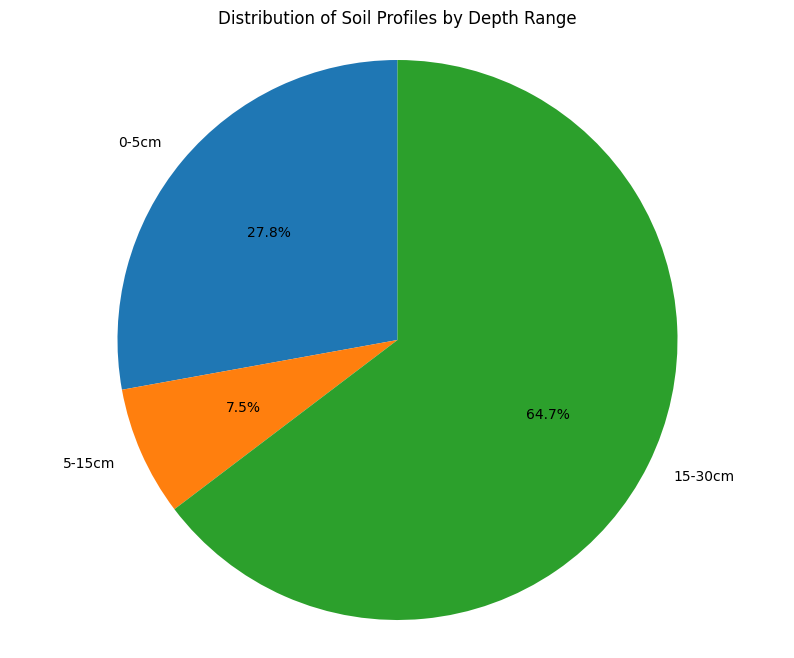

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define depth ranges
ranges = [(0, 5), (5, 15), (15, 30)]
counts = []

# Count profiles in each range
for start, end in ranges:
    mask = (filtered_gdf['upper_depth'] >= start) & (filtered_gdf['lower_depth'] <= end)
    count = filtered_gdf[mask]['profile_id'].nunique()
    counts.append(count)

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(counts, 
        labels=[f'{r[0]}-{r[1]}cm' for r in ranges],
        autopct='%1.1f%%',
        startangle=90)
plt.title('Distribution of Soil Profiles by Depth Range')
plt.axis('equal')
plt.show()


# Soil Profile Depth Distribution Analysis

This section analyzes how well the soil profiles are distributed across the 0-30cm depth range. We will:
1. Identify profiles with multiple depth records
2. Analyze depth coverage per profile
3. Visualize the depth distribution patterns

In [5]:
# Get profile depth coverage information
profile_depth_info = filtered_gdf.groupby('profile_id').agg({
    'upper_depth': ['min', 'count'],
    'lower_depth': ['max'],
    'soil_type': 'first',
    'orgc': 'mean'
}).reset_index()

# Flatten the MultiIndex columns
profile_depth_info.columns = ['profile_id', 'min_depth', 'depth_records', 'max_depth', 'soil_type', 'mean_orgc']

# Calculate depth coverage (difference between max and min depth)
profile_depth_info['depth_coverage'] = profile_depth_info['max_depth'] - profile_depth_info['min_depth']

# Create depth coverage categories
bins = [0, 5, 15, 30, float('inf')]
labels = ['0-5cm', '5-15cm', '15-30cm', '>30cm']
profile_depth_info['coverage_category'] = pd.cut(profile_depth_info['depth_coverage'], bins=bins, labels=labels)

# Check if profile starts near surface (0-5cm)
profile_depth_info['starts_near_surface'] = profile_depth_info['min_depth'] <= 5

# Define well-distributed profiles (starts near surface, covers at least 15cm, has multiple records)
profile_depth_info['well_distributed'] = (profile_depth_info['starts_near_surface'] & 
                                          (profile_depth_info['depth_coverage'] >= 15) & 
                                          (profile_depth_info['depth_records'] > 1))

# Single record with good coverage (starts near surface, depth at least 15cm)
profile_depth_info['single_good_coverage'] = (profile_depth_info['starts_near_surface'] & 
                                              (profile_depth_info['depth_coverage'] >= 15) & 
                                              (profile_depth_info['depth_records'] == 1))

print(f"Shape of the profile depth information: {profile_depth_info.shape}")
print(f"Number of well-distributed profiles: {profile_depth_info['well_distributed'].sum()}")
profile_depth_info.head(10)

Shape of the profile depth information: (851, 11)
Number of well-distributed profiles: 834


,profile_id,min_depth,depth_records,max_depth,soil_type,mean_orgc,depth_coverage,coverage_category,starts_near_surface,well_distributed,single_good_coverage
0,1149132,0,2,30,LUVISOL CROMICO,14.000000,30,15-30cm,True,True,False
1,1149188,0,2,20,CAMBISOL DISTRICO,44.000000,20,15-30cm,True,True,False
2,1149220,0,2,26,VERTISOL PELICO,19.000000,26,15-30cm,True,True,False
3,1149271,0,2,30,LUVISOL CROMICO,0.500000,30,15-30cm,True,True,False
4,1149276,0,2,30,NITOSOL EUTRICO,22.500000,30,15-30cm,True,True,False
5,1149299,0,2,21,GLEYSOL VERTICO,20.500000,21,15-30cm,True,True,False
6,1149311,0,2,29,REGOSOL EUTRICO,1.500000,29,15-30cm,True,True,False
7,1149325,0,2,28,REGOSOL EUTRICO,9.000000,28,15-30cm,True,True,False
8,1149339,0,2,25,LITOSOL,18.500000,25,15-30cm,True,True,False
9,1149374,0,3,30,XEROSOL LUVICO,3.333333,30,15-30cm,True,True,False


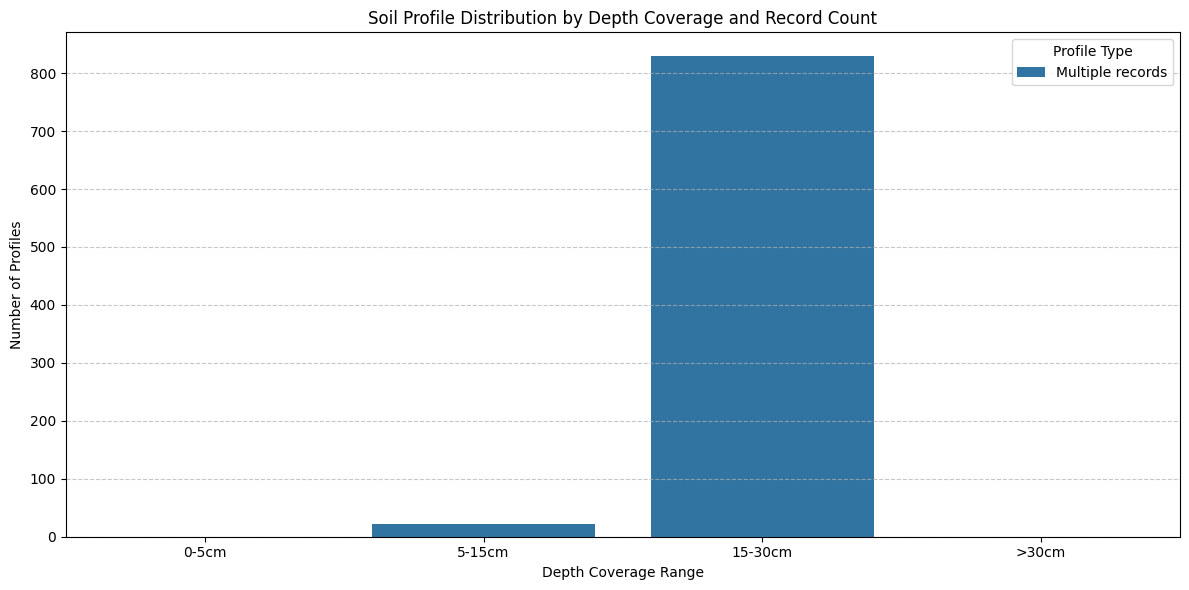

In [6]:
import seaborn as sns

# Plot distribution of depth coverage
plt.figure(figsize=(12, 6))

# Create a stacked bar chart showing profile distribution by depth coverage and record count
sns.countplot(data=profile_depth_info, x='coverage_category', 
              hue=profile_depth_info['depth_records'].apply(lambda x: 'Multiple records' if x > 1 else 'Single record'))

plt.title('Soil Profile Distribution by Depth Coverage and Record Count')
plt.xlabel('Depth Coverage Range')
plt.ylabel('Number of Profiles')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Profile Type')
plt.tight_layout()
plt.show()

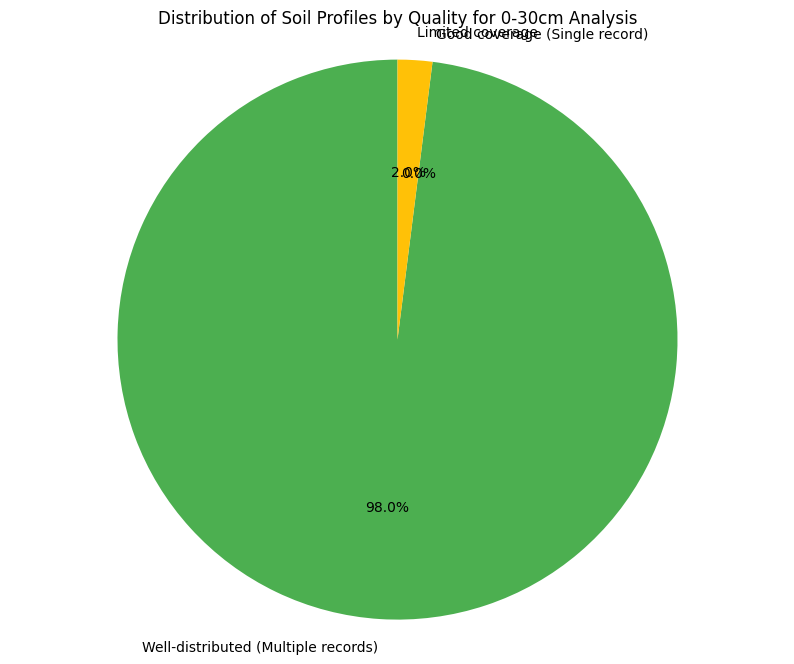

Total profiles analyzed: 851
Profiles with well-distributed multiple depth records: 834
Profiles with single record but good coverage: 0


In [7]:
# Analyzing profile quality for 0-30cm soil analysis
quality_counts = pd.DataFrame({
    'Profile Type': ['Well-distributed (Multiple records)', 'Good coverage (Single record)', 'Limited coverage'],
    'Count': [profile_depth_info['well_distributed'].sum(), 
              profile_depth_info['single_good_coverage'].sum(),
              len(profile_depth_info) - profile_depth_info['well_distributed'].sum() - profile_depth_info['single_good_coverage'].sum()]
})

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(quality_counts['Count'], labels=quality_counts['Profile Type'], autopct='%1.1f%%', startangle=90,
        colors=['#4CAF50', '#2196F3', '#FFC107'])
plt.title('Distribution of Soil Profiles by Quality for 0-30cm Analysis')
plt.axis('equal')
plt.show()

print(f"Total profiles analyzed: {len(profile_depth_info)}")
print(f"Profiles with well-distributed multiple depth records: {profile_depth_info['well_distributed'].sum()}")
print(f"Profiles with single record but good coverage: {profile_depth_info['single_good_coverage'].sum()}")

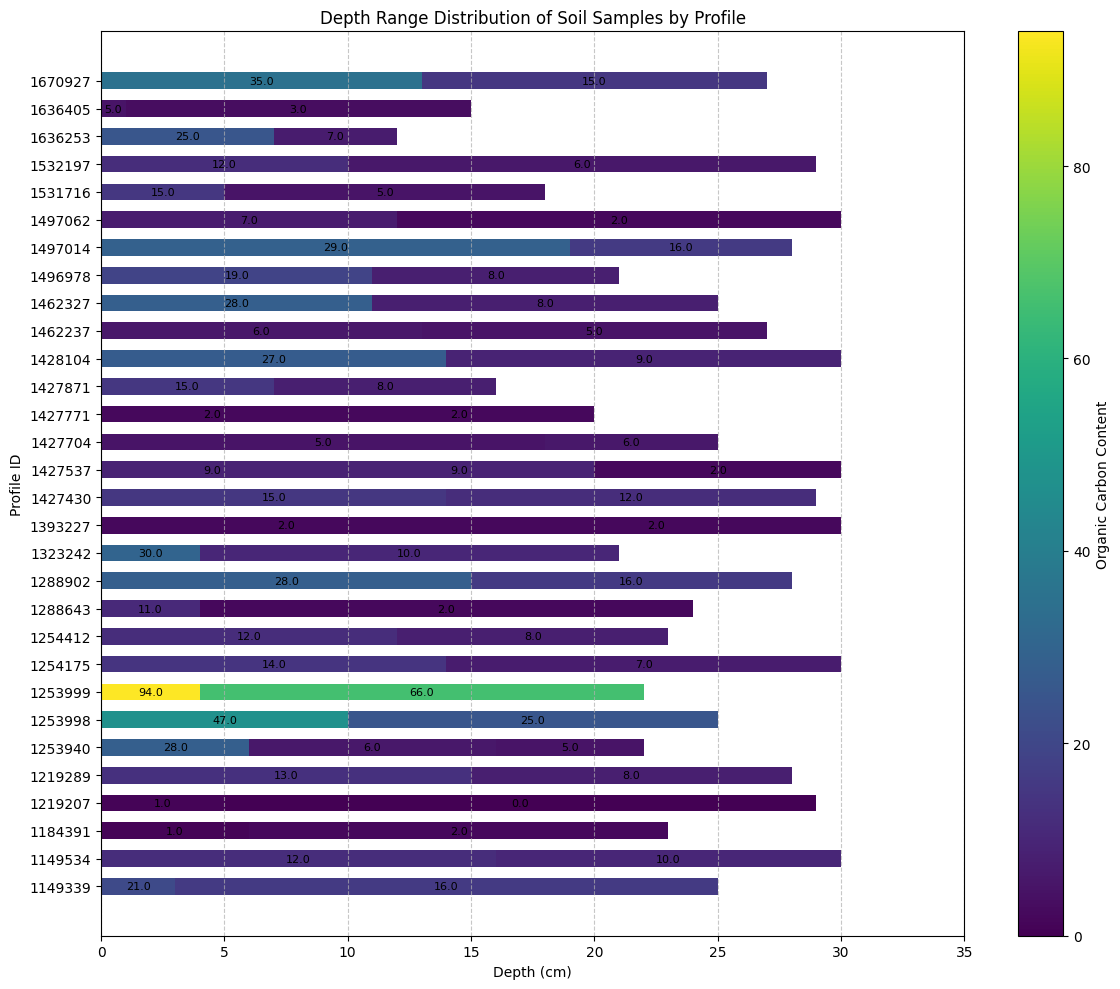

In [8]:
# Visualize depth ranges for a sample of profiles
# Selecting a sample of profiles that have multiple records
multi_record_profiles = profile_depth_info[profile_depth_info['depth_records'] > 1]['profile_id'].sample(min(30, sum(profile_depth_info['depth_records'] > 1)))

# Get all measurements for these profiles
sample_data = filtered_gdf[filtered_gdf['profile_id'].isin(multi_record_profiles)]

# Create a horizontal bar chart showing depth ranges for each profile
plt.figure(figsize=(12, 10))

# For each profile, plot its depth ranges
for i, profile in enumerate(sorted(sample_data['profile_id'].unique())):
    profile_data = sample_data[sample_data['profile_id'] == profile]
    
    for _, row in profile_data.iterrows():
        plt.barh(i, row['lower_depth'] - row['upper_depth'], left=row['upper_depth'], 
                height=0.6, color=plt.cm.viridis(row['orgc']/sample_data['orgc'].max()))
        
        # Add text showing orgc value
        midpoint = (row['upper_depth'] + row['lower_depth']) / 2
        plt.text(midpoint, i, f"{row['orgc']:.1f}", ha='center', va='center', fontsize=8)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=sample_data['orgc'].max()))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Organic Carbon Content')
 
# Set y-ticks to profile IDs
plt.yticks(range(len(multi_record_profiles)), sorted(multi_record_profiles))

# Set x-axis limit and add grid
plt.xlim(0, 35)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add labels and title
plt.xlabel('Depth (cm)')
plt.ylabel('Profile ID')
plt.title('Depth Range Distribution of Soil Samples by Profile')
plt.tight_layout()
plt.show()

## Save Well-Distributed Profiles for Analysis

Now we'll save the profiles that have good coverage of the 0-30cm depth range for further analysis.

In [9]:
import os

# Create a directory for well-distributed profiles
well_distributed_dir = os.path.join(base_path, 'depth_coverage')
os.makedirs(well_distributed_dir, exist_ok=True)

# Get IDs of well-distributed profiles
well_distributed_ids = profile_depth_info[profile_depth_info['well_distributed']]['profile_id']
single_good_coverage_ids = profile_depth_info[profile_depth_info['single_good_coverage']]['profile_id']

# Filter the original dataframe
well_distributed_data = filtered_gdf[filtered_gdf['profile_id'].isin(well_distributed_ids)]
single_record_data = filtered_gdf[filtered_gdf['profile_id'].isin(single_good_coverage_ids)]

# Save to CSV
well_distributed_data.to_csv(os.path.join(well_distributed_dir, 'well_distributed_profiles.csv'), index=False)
single_record_data.to_csv(os.path.join(well_distributed_dir, 'single_record_good_coverage.csv'), index=False)

print(f"Saved {len(well_distributed_data)} records from {len(well_distributed_ids)} well-distributed profiles")
print(f"Saved {len(single_record_data)} records from {len(single_good_coverage_ids)} single-record profiles with good coverage")

Saved 1710 records from 834 well-distributed profiles
Saved 0 records from 0 single-record profiles with good coverage


In [11]:
import os
import shutil

# Create a directory for each soil type
output_path = os.path.join(base_path, 'soil_type_splits')
# delete the directory and its contents if it exists
if os.path.exists(output_path):
    shutil.rmtree(output_path)

os.makedirs(output_path, exist_ok=True)

# Group by soil type and save each group to a separate file
for soil_type in filtered_gdf['soil_type'].unique():
    if pd.isna(soil_type):
        continue
        
    # Get subset for this soil type
    subset = filtered_gdf[filtered_gdf['soil_type'] == soil_type]
    
    # Create filename - replace spaces with underscores and convert to lowercase
    filename = soil_type.strip().replace(' ', '_').lower() + '.csv'
    
    # Save to CSV
    file_path = os.path.join(output_path, filename)
    subset.to_csv(file_path, index=False)
    print(f"Saved {len(subset)} rows to {filename}")

Saved 62 rows to xerosol_luvico.csv
Saved 4 rows to planosol_molico.csv
Saved 15 rows to luvisol_ferrico.csv
Saved 266 rows to regosol_eutrico.csv
Saved 155 rows to feozem_haplico.csv
Saved 21 rows to yermosol_calcico.csv
Saved 114 rows to xerosol_haplico.csv
Saved 24 rows to feozem_luvico.csv
Saved 44 rows to planosol_eutrico.csv
Saved 62 rows to luvisol_cromico.csv
Saved 30 rows to vertisol_pelico.csv
Saved 18 rows to cambisol_calcico_(calcarico).csv
Saved 12 rows to yermosol_luvico.csv
Saved 11 rows to solonetz_albico.csv
Saved 187 rows to litosol.csv
Saved 78 rows to xerosol_calcico.csv
Saved 19 rows to fluvisol_eutrico.csv
Saved 48 rows to rendzina.csv
Saved 2 rows to gleysol_humico.csv
Saved 21 rows to acrisol_humico.csv
Saved 18 rows to fluvisol_calcarico.csv
Saved 6 rows to andosol_humico.csv
Saved 46 rows to cambisol_cromico.csv
Saved 59 rows to solonchak_ortico.csv
Saved 50 rows to vertisol_cromico.csv
Saved 6 rows to cambisol_ferralico.csv
Saved 2 rows to luvisol_plintico.cs

In [ ]:
# features = ['clay', 'silt', 'sand', 'phaq', target]

# # drop rows where the values in features are -9999
# for feature in features:
#     mex_gdf = mex_gdf[mex_gdf[feature] != -9999]
# print(f"Shape of the dataset after dropping -9999 values: {mex_gdf.shape}")

# # drop duplicates ignoring the depth_category column that could be different
# mex_gdf = mex_gdf.drop_duplicates(subset=features, keep='first')
# print(f"Shape of the dataset after dropping duplicates: {mex_gdf.shape}")

# # drop rows where profile_id is occurring only once
# mex_gdf = mex_gdf[mex_gdf['profile_id'].map(mex_gdf['profile_id'].value_counts()) > 1]
# print(f"Shape of the dataset after dropping profile_ids with single depths: {mex_gdf.shape}")

# # reset index
# mex_gdf = mex_gdf.reset_index(drop=True)

# mex_gdf.head()